Saving przykladowe_dane_ml.csv to przykladowe_dane_ml (5).csv
Podgląd danych:
         Data  Wartość
0  2024-01-01       99
1  2024-01-02       69
2  2024-01-03       41
3  2024-01-04       46
4  2024-01-05       75

Brakujące wartości w kolumnach:
Data       0
Wartość    0
dtype: int64

Statystyki opisowe:
        Wartość
count  30.00000
mean   59.90000
std    25.67348
min    12.00000
25%    38.00000
50%    64.00000
75%    77.25000
max    99.00000

Macierz korelacji:
         Wartość
Wartość      1.0


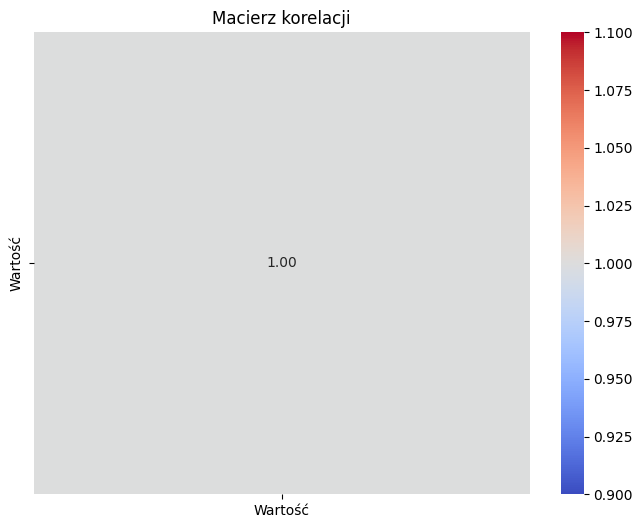

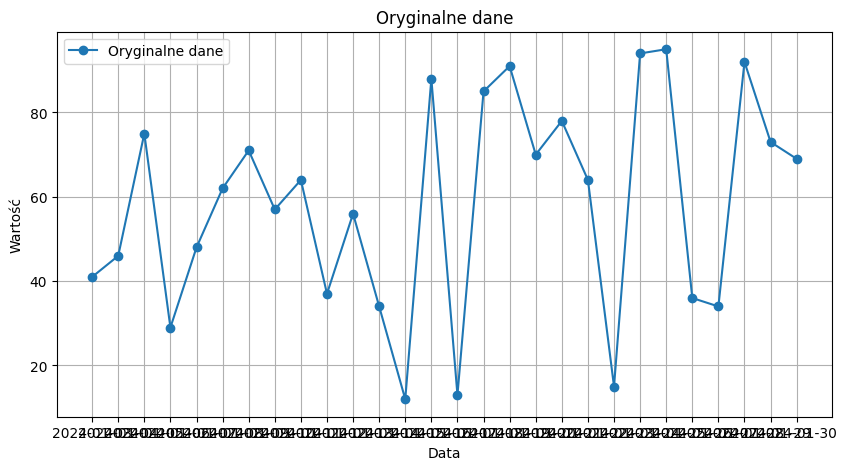

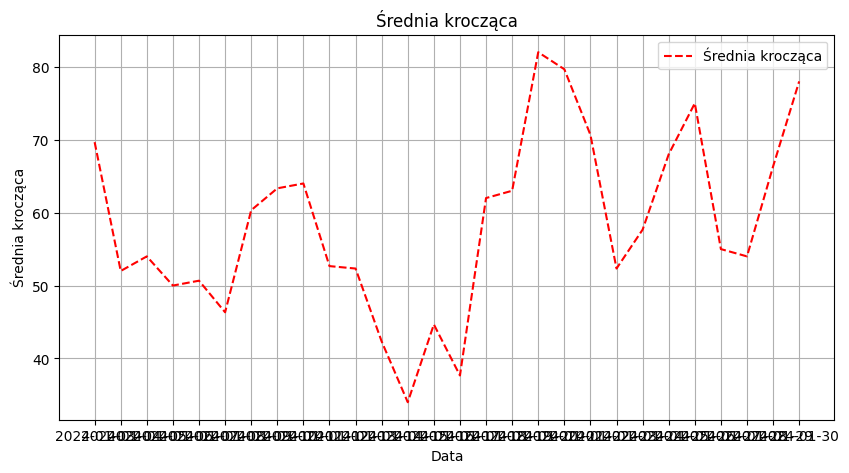

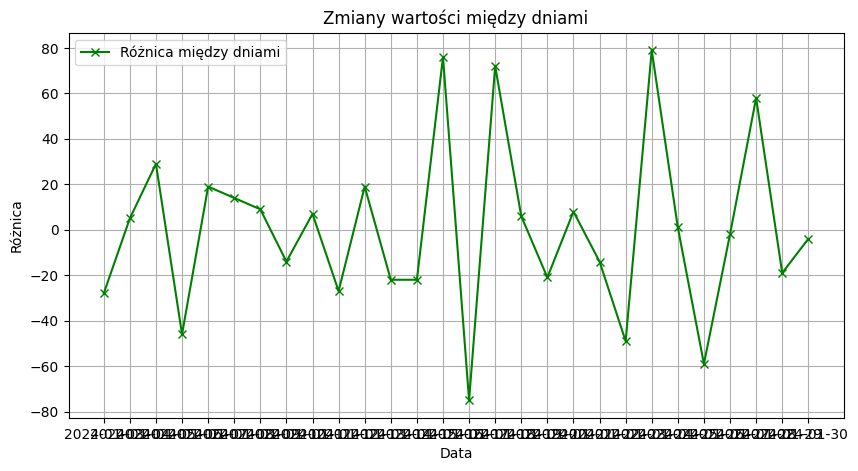


Zestaw treningowy: X_train shape: (22, 3) y_train shape: (22,)
Zestaw testowy: X_test shape: (6, 3) y_test shape: (6,)


In [8]:
# Importowanie bibliotek
import pandas as pd
import matplotlib.pyplot as plt
#Seaborn to biblioteka Pythona służąca do wizualizacji danych, oparta na matplotlib i zintegrowana z pandas.
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Wczytanie pliku CSV (możesz przesłać swój plik do Google Colab)
from google.colab import files
uploaded = files.upload()

# Odczytanie pliku CSV do DataFrame
filename = list(uploaded.keys())[0]  # Pobranie nazwy przesłanego pliku
df = pd.read_csv(filename)

# Wyświetlenie pierwszych kilku wierszy danych
print("Podgląd danych:")
print(df.head())

# Sprawdzenie brakujących wartości
total_missing = df.isnull().sum()
print("\nBrakujące wartości w kolumnach:")
print(total_missing)

# Podstawowe statystyki opisowe
descriptive_stats = df.describe()
print("\nStatystyki opisowe:")
print(descriptive_stats)

# Analiza korelacji między zmiennymi
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

print("\nMacierz korelacji:")
print(correlation_matrix)

# Wizualizacja macierzy korelacji
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

# Dodanie nowej kolumny - średnia krocząca (rolling mean) z oknem 3
df["Średnia_krocząca"] = df.iloc[:, 1].rolling(window=3).mean()

# Obliczenie różnicy między kolejnymi wartościami (diff)
df["Różnica"] = df.iloc[:, 1].diff()

# Normalizacja wartości (min-max scaling)
scaler = MinMaxScaler()
df["Wartość_znormalizowana"] = scaler.fit_transform(df.iloc[:, 1].values.reshape(-1,1))

# Usunięcie pierwszego wiersza z brakującymi wartościami po różnicy
df = df.dropna()

# Wizualizacja oryginalnych danych
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Oryginalne dane', marker='o')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.title('Oryginalne dane')
plt.legend()
plt.grid()
plt.show()

# Wizualizacja średniej kroczącej
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:, 0], df["Średnia_krocząca"], label='Średnia krocząca', linestyle='--', color='r')
plt.xlabel('Data')
plt.ylabel('Średnia krocząca')
plt.title('Średnia krocząca')
plt.legend()
plt.grid()
plt.show()

# Wizualizacja różnicy między kolejnymi wartościami
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:, 0], df["Różnica"], label='Różnica między dniami', color='g', marker='x')
plt.xlabel('Data')
plt.ylabel('Różnica')
plt.title('Zmiany wartości między dniami')
plt.legend()
plt.grid()
plt.show()

# Przygotowanie danych dla uczenia maszynowego
X = df[["Średnia_krocząca", "Różnica", "Wartość_znormalizowana"]]
y = df.iloc[:, 1]  # Cel do przewidywania

# Podział na zestaw treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nZestaw treningowy: X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("Zestaw testowy: X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

# Nowa sekcja